In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/processed/tweets_sentiment.csv")
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")

print(f"✅ {len(df)} satır yüklendi")

C:\Users\Eser\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ 1695 satır yüklendi


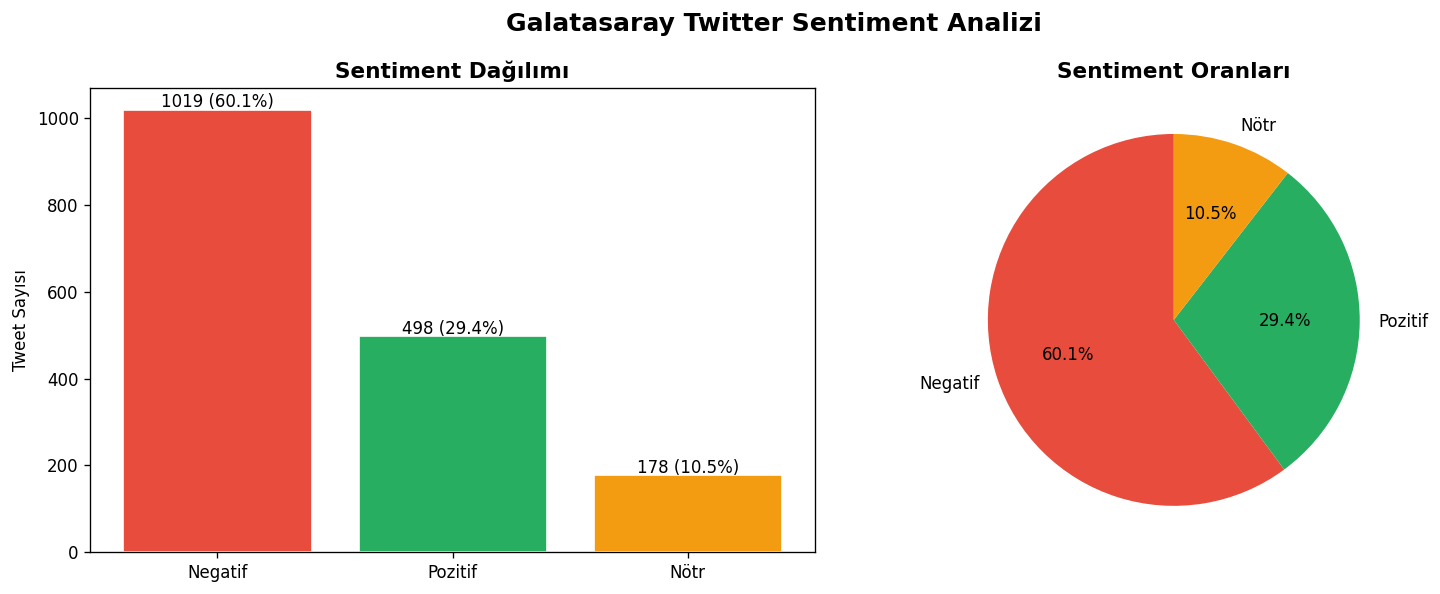

In [2]:
colors = {"Pozitif": "#27ae60", "Nötr": "#f39c12", "Negatif": "#e74c3c"}
counts = df["sentiment"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bar_c = [colors[s] for s in counts.index]
axes[0].bar(counts.index, counts.values, color=bar_c, edgecolor="white")
axes[0].set_title("Sentiment Dağılımı", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Tweet Sayısı")
for i, (l, v) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, v + 5, f"{v} ({v/len(df)*100:.1f}%)", ha="center", fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=[colors[s] for s in counts.index],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Sentiment Oranları", fontsize=13, fontweight="bold")

plt.suptitle("Galatasaray Twitter Sentiment Analizi", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/01_sentiment_dagilim.png", bbox_inches="tight")
plt.show()

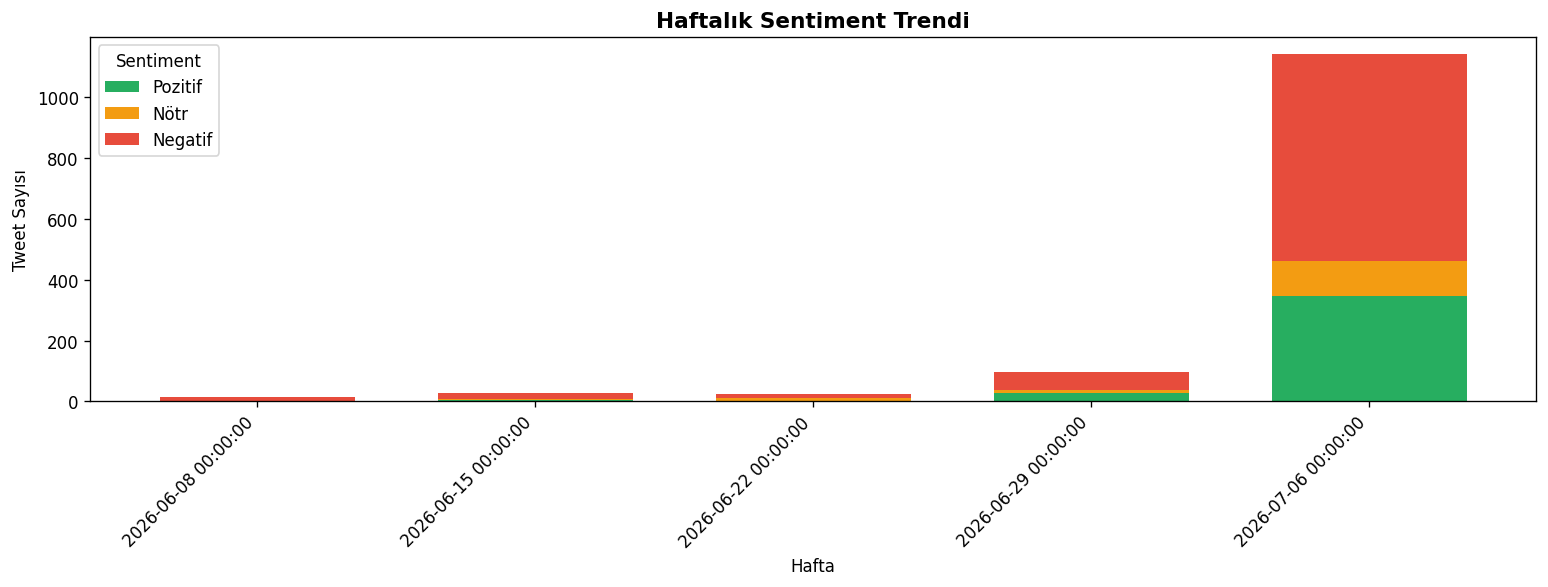

In [3]:
import os
os.makedirs("../outputs/figures", exist_ok=True)

son_30 = df[df["created_at"] >= df["created_at"].max() - pd.Timedelta(days=30)]

son_30["week"] = son_30["created_at"].dt.to_period("W").dt.start_time
weekly = (son_30.groupby(["week", "sentiment"]).size().unstack(fill_value=0)
            .reindex(columns=["Pozitif", "Nötr", "Negatif"], fill_value=0))

fig, ax = plt.subplots(figsize=(13, 5))
weekly.plot(kind="bar", stacked=True, ax=ax,
            color=["#27ae60", "#f39c12", "#e74c3c"], width=0.7)
ax.set_title("Haftalık Sentiment Trendi", fontsize=13, fontweight="bold")
ax.set_xlabel("Hafta")
ax.set_ylabel("Tweet Sayısı")
ax.legend(title="Sentiment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/02_haftalik_trend.png", bbox_inches="tight")
plt.show()

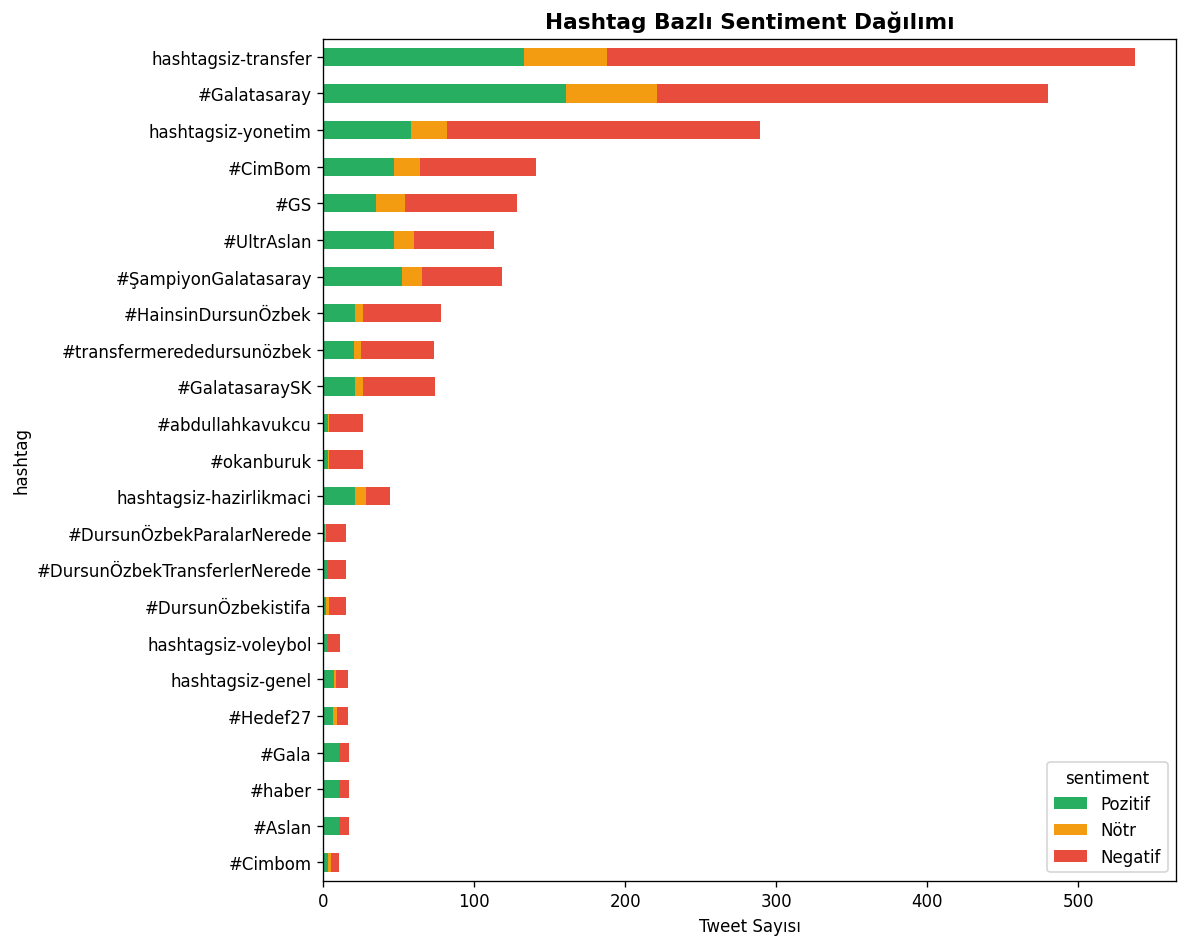

In [4]:
# search_term'i + ile böl, her hashtag'i ayrı satır yap
df_exp = df.copy()
df_exp["hashtag"] = df_exp["search_term"].str.split("+")
df_exp = df_exp.explode("hashtag")
df_exp["hashtag"] = df_exp["hashtag"].str.strip()

# En az 10 tweet olan hashtag'ler
hashtag_sentiment = (df_exp.groupby(["hashtag", "sentiment"])
                     .size()
                     .unstack(fill_value=0)
                     .reindex(columns=["Pozitif", "Nötr", "Negatif"], fill_value=0))
hashtag_sentiment = hashtag_sentiment[hashtag_sentiment.sum(axis=1) >= 10]
hashtag_sentiment = hashtag_sentiment.sort_values("Negatif", ascending=True)

hashtag_sentiment.plot(kind="barh", stacked=True, figsize=(10, 8),
                       color=["#27ae60", "#f39c12", "#e74c3c"])
plt.title("Hashtag Bazlı Sentiment Dağılımı", fontsize=13, fontweight="bold")
plt.xlabel("Tweet Sayısı")
plt.tight_layout()
plt.savefig("../outputs/figures/03_hashtag_sentiment.png", bbox_inches="tight")
plt.show()

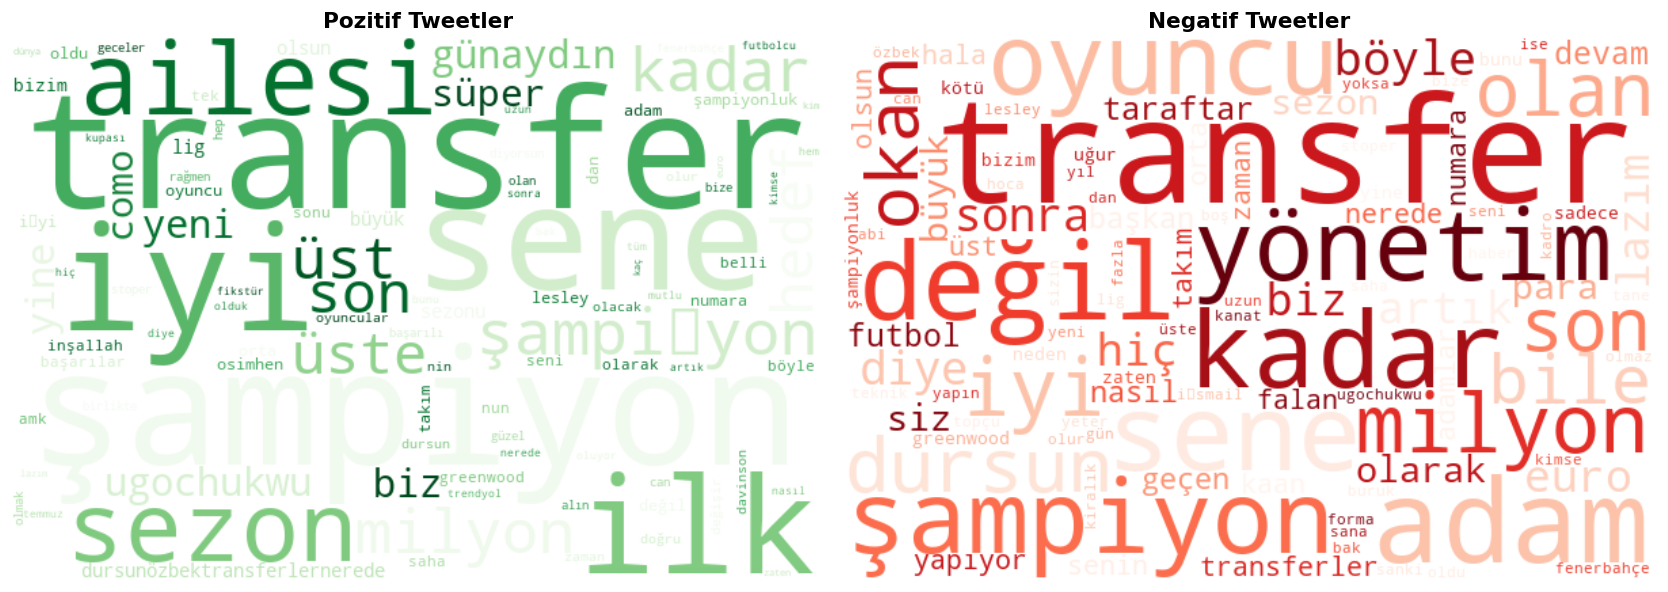

In [5]:
STOPWORDS = {"bir","bu","ve","da","de","ile","için","ne","o","ya","ki",
             "ama","çok","en","daha","var","yok","gibi","her","ben","sen",
             "rt","galatasaray","gs","cimbom","amp"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, label, cmap in zip(axes, ["Pozitif", "Negatif"], ["Greens", "Reds"]):
    words = " ".join(df[df["sentiment"] == label]["clean_text"].dropna())
    tokens = [w for w in words.split() if w not in STOPWORDS and len(w) > 2]
    freq = Counter(tokens)
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap=cmap, max_words=100, collocations=False)
    wc.generate_from_frequencies(freq)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{label} Tweetler", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/04_kelime_bulutu.png", bbox_inches="tight")
plt.show()